In [112]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer, rotator
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

import glob
import os


In [113]:
df=pd.read_excel(r'C:\Users\johan\Documents\Documents\School\EDA_course\lab1\stockreturns.xlsx',header=None)

df

,0,1,2,3,4,5,6,7,8,9
0,0.447813,0.067331,0.150311,2.991352,-0.207695,0.455964,-0.781059,0.205240,-0.001368,1.464562
1,0.988109,1.581645,-0.611253,2.620408,0.535787,0.589932,1.207660,1.065817,-0.551631,0.202665
2,0.874563,0.756208,-2.180025,-0.362371,1.371877,0.918730,1.114681,1.544983,1.523075,0.347807
3,0.714403,-0.689844,0.253764,2.209370,0.580143,1.837029,0.919674,0.422198,-0.417153,-1.009343
4,0.005351,-1.342888,-2.064859,-2.407927,-0.186868,-0.172721,0.154608,-1.103909,0.203125,1.997488
...,...,...,...,...,...,...,...,...,...,...
95,-1.202835,-0.475408,0.878834,-5.016160,-1.827819,-1.073763,0.045913,0.821147,0.995893,-1.238048
96,0.033411,-0.294351,-3.466637,0.385052,0.175829,-0.500618,-2.314474,0.121723,-1.052358,-0.665537
97,1.104768,2.051862,0.926894,0.533393,-0.694438,-1.091278,-4.363289,1.244669,1.244691,0.273739
98,2.228001,1.716761,1.629434,1.438094,1.167099,0.200579,1.614918,-0.426848,-0.029258,-2.649804


In [114]:
column_names=[1,2,3,4,5,6,7,8,9,10]
df.columns=column_names
print(df.describe())
print(df.info())
print(df.isna().sum())

#center data and standarizr to scale to unit variance
Z=StandardScaler(with_mean=True,with_std=True).fit_transform(df)

R=np.corrcoef(Z,rowvar=False)


               1           2           3           4           5           6   \
count  100.000000  100.000000  100.000000  100.000000  100.000000  100.000000   
mean    -0.205973   -0.185383   -0.417730   -0.000587   -0.041528   -0.079531   
std      1.042490    1.266151    1.602665    2.359008    0.997932    1.327798   
min     -3.496073   -2.561813   -4.438418   -5.876362   -2.567118   -3.419913   
25%     -0.787180   -1.092094   -1.774183   -1.498274   -0.686821   -0.967786   
50%     -0.198705   -0.284070   -0.388363    0.061700    0.076987   -0.066803   
75%      0.409016    0.701761    0.821638    1.680436    0.564746    0.980467   
max      2.228001    3.180881    2.925340    6.469176    2.073680    2.741017   

               7           8           9           10  
count  100.000000  100.000000  100.000000  100.000000  
mean     0.166941   -0.139690   -0.108592    0.030517  
std      1.708513    1.084282    1.333681    1.497075  
min     -4.650008   -2.496761   -3.986496   -3

### scree plot for picking m

[3.02286632 2.20308075 1.35438718 0.85930551 0.68266141 0.6194473
 0.49103372 0.33732547 0.24042265 0.1894697 ]


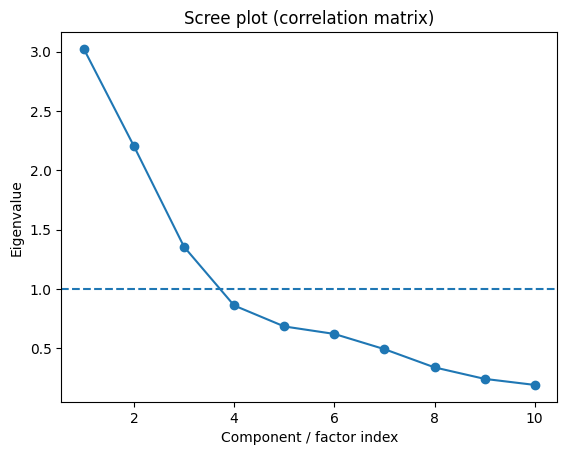

In [115]:

eigvals=np.linalg.eigvalsh(R) # extract eigenvals
eigvals=eigvals[::-1] # reverse order to descending
print(eigvals)
plt.plot(range(1,len(eigvals)+1),eigvals, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Component / factor index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (correlation matrix)")
plt.show()

In [116]:
def plot(scores,title=None):
    pairs = [(0,1), (0,2), (1,2)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False, sharey=False)
    titles = ["F1 vs F2", "F1 vs F3", "F2 vs F3"]
    for ax, (a, b), t in zip(axes, pairs, titles):
        ax.scatter(scores[:, a], scores[:, b], s=12, alpha=0.7)
        ax.axhline(0)
        ax.axvline(0)
        ax.set_xlabel(f"Factor {a+1} score")
        ax.set_ylabel(f"Factor {b+1} score")
        ax.set_title(t+f"({title})")

    plt.tight_layout()
    plt.show()
        


In [ ]:
def factor_analysis(rotation='varimax',m=0, method='minres',svd_method='lapack',matr):
    fa_ = FactorAnalyzer(n_factors=m, rotation= rotation, method=method,svd_method=svd_method)
    fa_.fit(matr)
    scores=fa_.transform(matr)
    plot(scores,rotation)

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


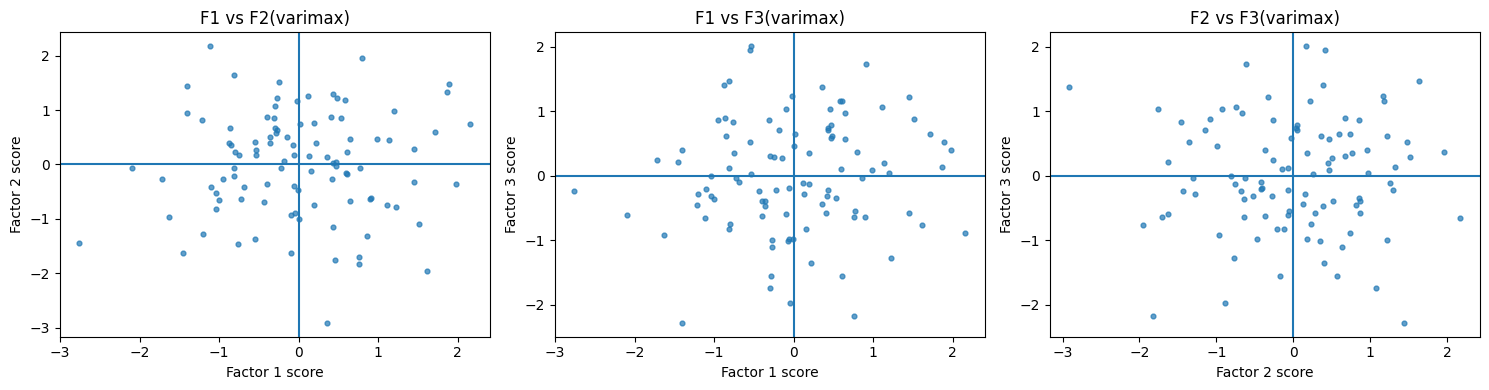

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


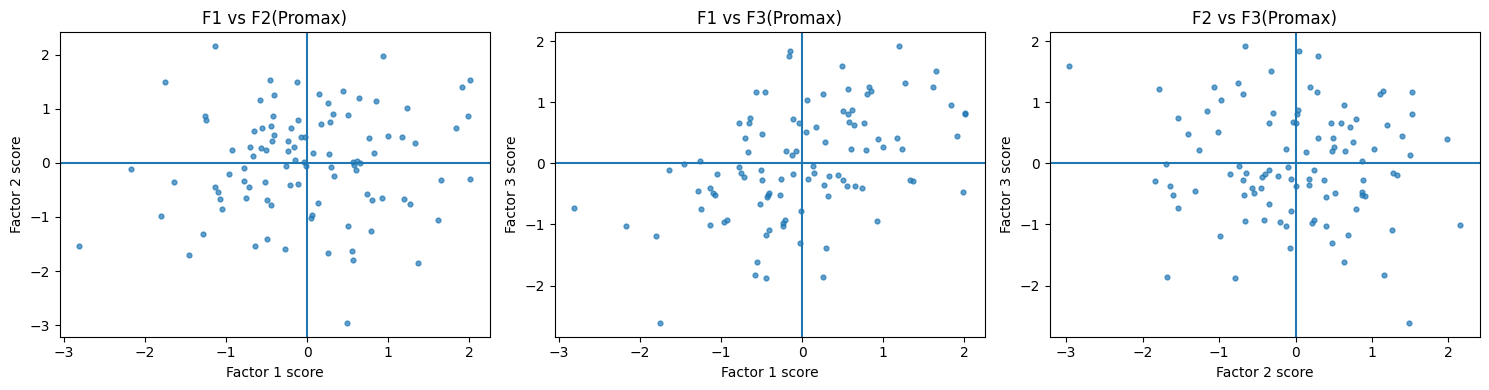

In [131]:

m=3 

fa_varimax = FactorAnalyzer(n_factors=m, rotation= 'varimax', method='minres',svd_method='lapack')
fa_varimax.fit(Z)
scores_varimax=fa_varimax.transform(Z)


plot(scores_varimax,'varimax')


fa_Promax = FactorAnalyzer(n_factors=m, rotation= 'Promax', method='minres',svd_method='lapack')
fa_Promax.fit(Z)
scores_quartimax=fa_Promax.transform(Z)
plot(scores_quartimax,'Promax')


In [118]:
def plot_loadings(loadings, feature_names=None, rotation=None):
    titles=["Loadings: F1 vs F2", "Loadings: F1 vs F3", "Loadings: F2 vs F3"]
    pairs=[(0,1),(0,2),(1,2)]# list of tuples f1,f2 f1,f3 & f2,f3
    fig, axis=plt.subplots( 1 , 3 , figsize=(15, 4))

    for t, (a, b), ax in zip(titles, pairs,axis):
        ax.scatter(loadings[:,a],loadings[:,b],c='red' )
        ax.axhline(0)
        ax.axvline(0)
        ax.legend(t)
        ax.set_xlabel(f"Factor{a+1} loading")
        ax.set_ylabel(f"Factor{b+1} loading")
        ax.set_title(rotation)
        for i, name in enumerate(feature_names):
            ax.text(loadings[i, a], loadings[i, b], name, fontsize=11)
    
    plt.show()    
    

[0.84510663 0.70774238 0.18907076 0.16499119 0.8868312  0.62164845
 0.29508644 0.70203918 0.62154268 0.34187522]
[[ 1.          0.0716995   0.38722069]
 [ 0.0716995   1.         -0.09927353]
 [ 0.38722069 -0.09927353  1.        ]]


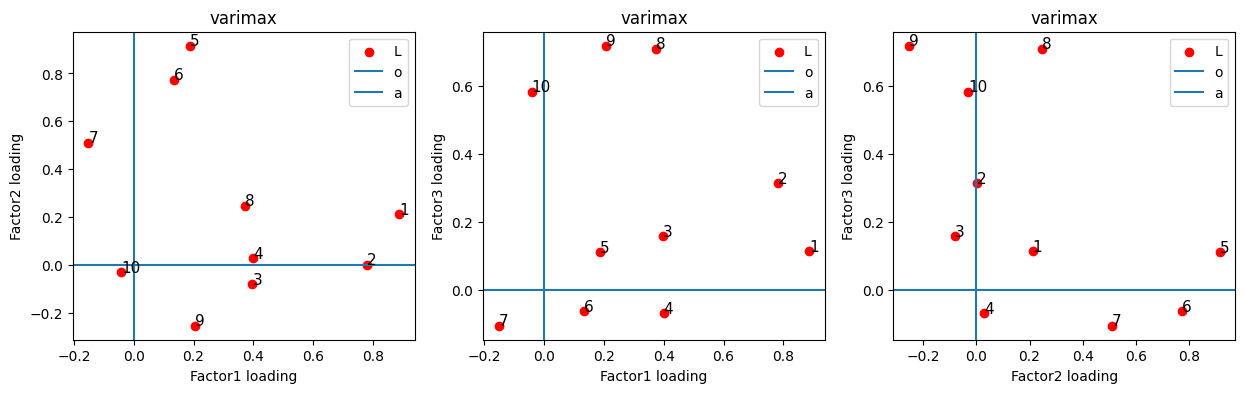

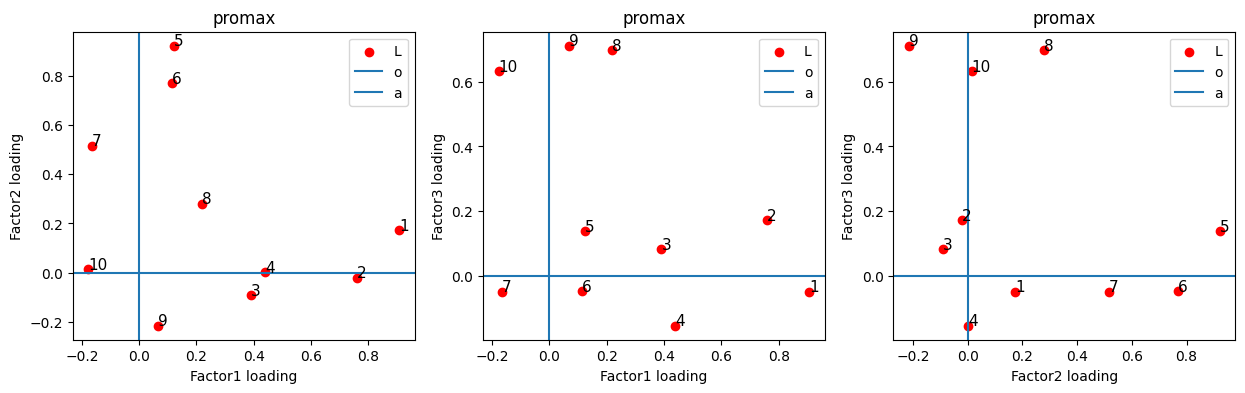

In [119]:
loadings_v=fa_varimax.loadings_
uniqueness_v=fa_varimax.get_uniquenesses()
communalities_v=fa_varimax.get_communalities()
tuple_v=fa_varimax.get_factor_variance()
loadings_pro=fa_Promax.loadings_
print(communalities_v)
print(fa_Promax.phi_)
loadings_v.shape #(10,3)
uniqueness_v.shape #(10,)
communalities_v.shape#(10,)
names=df.columns.to_list()
plot_loadings(loadings_v,names,'varimax')
plot_loadings(loadings_pro,names,'promax')

(100, 10)


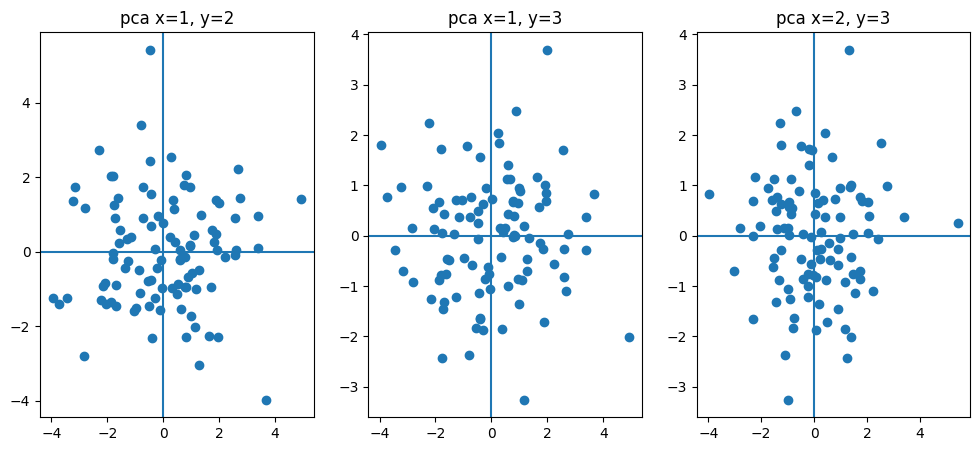

In [120]:
eigval,eigvec=np.linalg.eigh(R)
eigval=eigval[::-1]
eigvec = eigvec[:, ::-1]
PC_1_3=eigvec[:,:3]
T1=Z @ eigvec
print(T1.shape)
fig, axis=plt.subplots(1,3,  figsize=(12, 5))
pairs=[(0,1),(0,2),(1,2)]
for ax,(a,b) in zip(axis, pairs):
    ax.scatter(T1[:,a],T1[:,b])
    ax.axhline(y=0)
    ax.axvline(x=0)
    ax.set_title(f"pca x={a+1}, y={b+1}")

###Q1-c


In [152]:
path1=r'C:\Users\johan\Documents\Documents\School\EDA_course\lab1\sw_stock_idx'
all_files = glob.glob(os.path.join(path1 , "*.csv"))# glob return list of paths, os.path.join find all files with csv extentions 
comp=['abb','atcoa','jm','ncca','ndadk','saabb','seba','shba','skab','volva']

li=[]
for file in all_files:
    df=pd.read_csv(file,sep=';', skiprows=1, usecols=[6]) #need semicolumn to seperate colomns, ship first row use column 6
    li.append(df)

frame = pd.concat(li, axis=1)
frame=frame.drop(axis=0, index=[20,21])

frame.columns=comp
frame=frame.pct_change().mul(100).fillna(0)
frame


,abb,atcoa,jm,ncca,ndadk,saabb,seba,shba,skab,volva
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-1.108247,0.160471,-0.444444,0.000000,-0.991277,2.453081,-0.507228,-0.244158,-0.973324,-3.106682
2,-0.416992,-1.869159,1.636905,-1.709402,-2.482980,0.721189,-2.447107,-1.678322,-1.383327,-1.996370
3,-7.720492,-0.136054,2.489019,0.434783,-0.451745,1.145639,-1.228116,0.106686,-0.738280,-0.308642
4,0.311968,-0.844687,1.071429,0.000000,3.135314,1.231771,7.248677,1.136767,-0.520640,0.247678
5,-2.092169,2.555647,-1.272085,-0.865801,1.440000,-1.958042,0.641342,0.456621,0.523364,-2.655960
6,-1.530465,1.982851,0.071582,0.000000,-1.222397,2.539230,-1.323529,-1.188811,-0.297508,0.253807
7,-0.557185,-0.367840,2.217454,-1.310044,-0.598802,-3.797997,-0.447094,-0.955414,0.708691,-0.189873
8,0.707756,0.474684,1.329601,-0.884956,1.726908,4.497469,1.097804,1.071811,0.629630,0.253646
9,1.346999,-0.446194,-1.312155,-2.232143,-2.487169,0.996402,-1.579467,-1.343231,-2.097902,-1.454775


[3.72485733 1.84845561 1.24166178 0.85953754 0.70568688 0.55820096
 0.47058666 0.34370474 0.19472561 0.0525829 ]


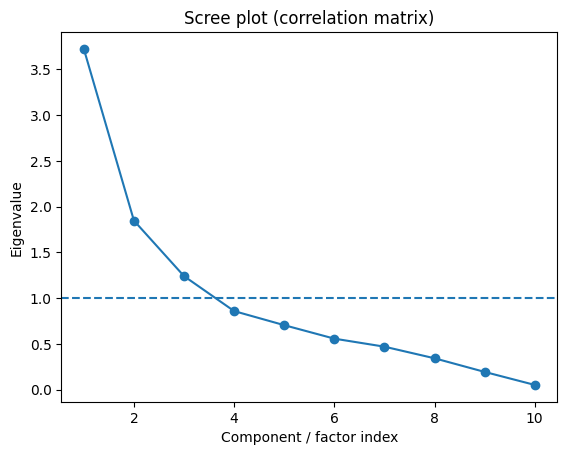

In [153]:

frame_z=StandardScaler(with_mean=True,with_std=True).fit_transform(frame)# standarize with centering and using unit variance

frame_r=np.corrcoef(frame_z,rowvar=False)


eigvals_C=np.linalg.eigvalsh(frame_r) # extract eigenvals
eigvals_C=eigvals_C[::-1] # reverse order to descending
print(eigvals_C)
plt.plot(range(1,len(eigvals_C)+1),eigvals_C, marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel("Component / factor index")
plt.ylabel("Eigenvalue")
plt.title("Scree plot (correlation matrix)")
plt.show()

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


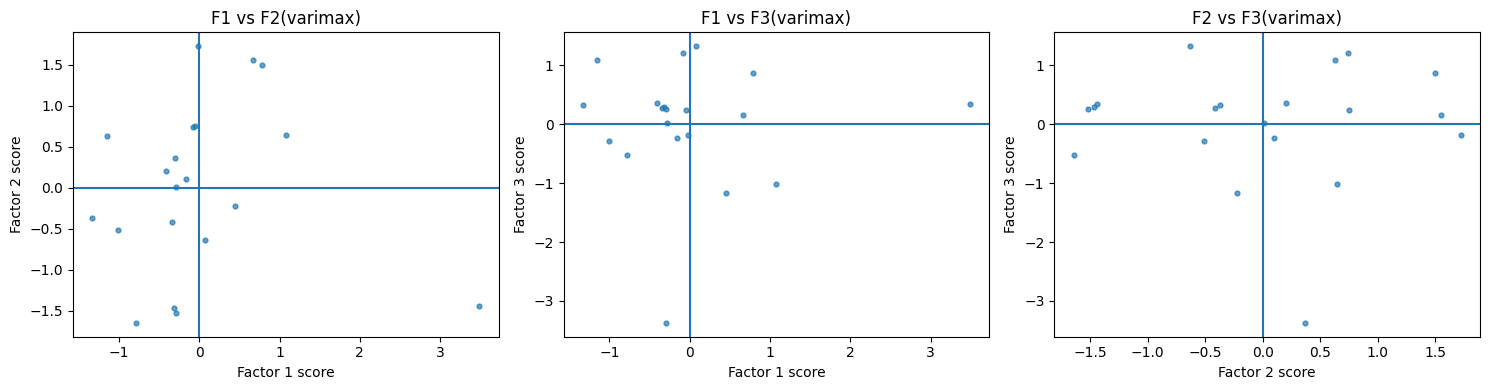

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


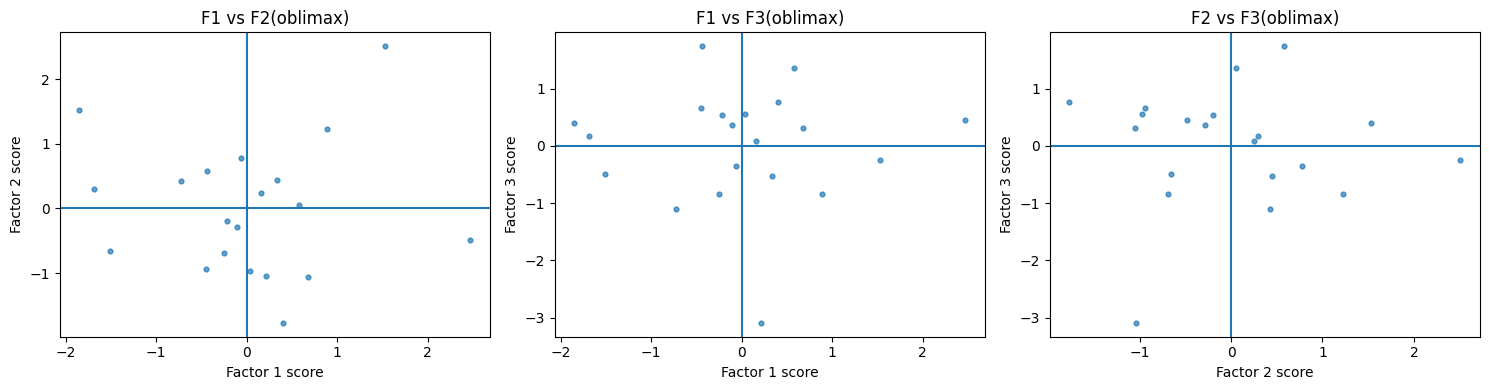

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


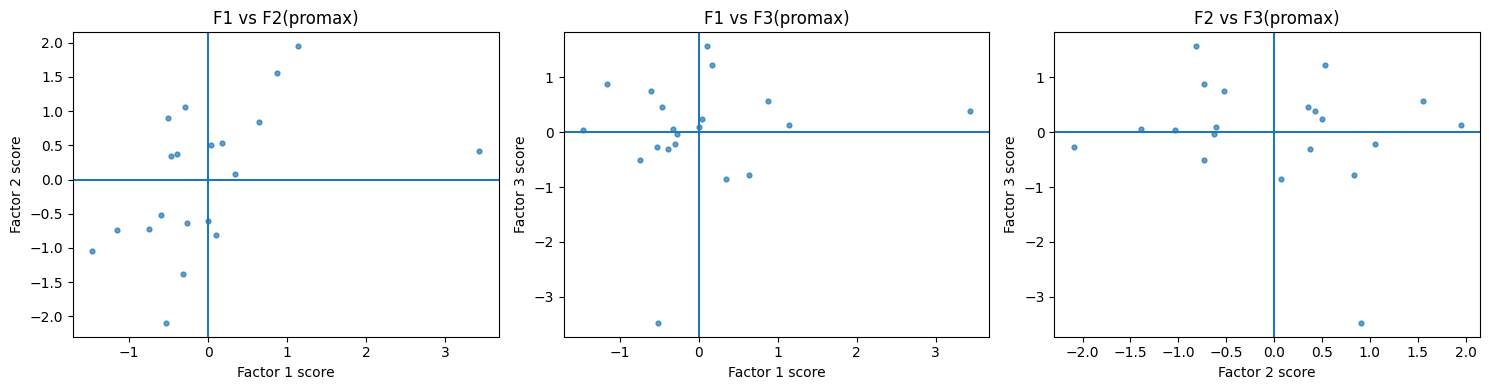

C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\johan\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


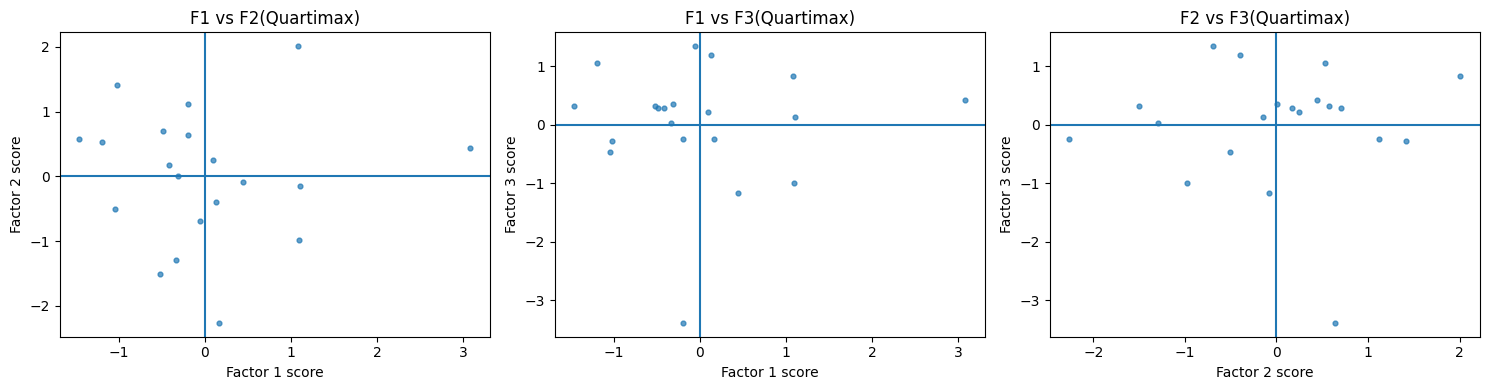

In [171]:
factor_analysis(rotation='varimax' , m=3 , method='principal' , svd_method='lapack')
factor_analysis(rotation='oblimax' , m=3 , method='principal' , svd_method='lapack')
factor_analysis(rotation='promax' , m=3 , method='principal' , svd_method='lapack')
factor_analysis(rotation='Quartimax' , m=3 , method='principal' , svd_method='lapack')


